## Setup, Loading Data and CDFs

In [ ]:
DATA_NAME = 'syntheticMRI2D-coronal' 
TRANSFORM = 'wavelet-horizontal'
CHANNEL = ''

In [2]:
path_list = DATA_NAME.split("-") + TRANSFORM.split("-")
if CHANNEL:
    path_list.append(CHANNEL)
print(f"Name the notebook:\n{'_'.join(path_list[::-1])}.ipynb")
FULL_DATA_NAME='-'.join(path_list)

Name the notebook:
horizontal_wavelet_coronal_syntheticMRI2D.ipynb


In [3]:
import git
from pathlib import Path
import os

ROOT_DIR = Path(git.Repo('.', search_parent_directories=True).working_tree_dir)

# CWD = os.path.join(ROOT_DIR, "results", "case-studies", *path_list)
CWD = os.path.join(ROOT_DIR, "anderson-darling")

assert CWD == os.getcwd()
Path(os.path.join(CWD, "CSVs")).mkdir(exist_ok=True)
Path(os.path.join(CWD, "plots")).mkdir(exist_ok=True)
Path(os.path.join(CWD, "cache")).mkdir(exist_ok=True)

GROUP = 'layer' if TRANSFORM.split("-")[0] == 'wavelet' else ('band' if TRANSFORM.split("-")[0] == 'fourier' else 'error')
RERUN = False
SKIP_OPTIMIZE_STEP = False
CWD

'/Users/michaelmurphy/Documents/GitHub/hierarchical-bayesian-model-validation/anderson-darling'

In [4]:
os.chdir(os.path.join(ROOT_DIR, "anderson-darling"))
from testing_ad import *
os.chdir(os.path.join(ROOT_DIR, "utilities"))
from testing import * # If MATLAB is not installed, open utilities and set to False
from plotting import *
os.chdir(CWD)
np.random.seed(0)

In [10]:
group_data_map = pd.read_pickle(os.path.join(ROOT_DIR, "transformed-data", f'{FULL_DATA_NAME}.pickle'))
group_total_samples = pd.read_pickle(os.path.join(ROOT_DIR, "transformed-data", f'{FULL_DATA_NAME}-size.pickle'))


In [11]:
if 'fourier' in TRANSFORM:
    GROUPS = np.arange(2, sorted(group_data_map)[-1] + 1)[::3]
elif 'wavelet' in TRANSFORM:
    GROUPS = np.arange(2, sorted(group_data_map)[-1] + 1)

#TODO 
keep_keys = [4,5]
group_data_map = {key: value for key, value in group_data_map.items() if key in keep_keys}
group_total_samples = {key: value for key, value in group_total_samples.items() if key in keep_keys}
GROUPS = keep_keys

cdfs_dir = os.path.join(ROOT_DIR, "results", "CDFs")
cdfs_list = sorted([os.path.join(cdfs_dir, i) for i in os.listdir(cdfs_dir)])
all_cdfs = combine_pickles(cdfs_list[0])
for cdf_dir in cdfs_list[:6]: # TODO For quick testing purposes. Currently excluding 20000 CDFs. Use cdfs_list[5:6] to access CDFs/_test
    all_cdfs = all_cdfs | combine_pickles(cdf_dir)
    
# group_data_map = {g : group_data_map[g][::100] for g in GROUPS} # TODO For quick testing purposes
group_total_samples

{4: 177766, 5: 820632}

Running 12760 CDFs


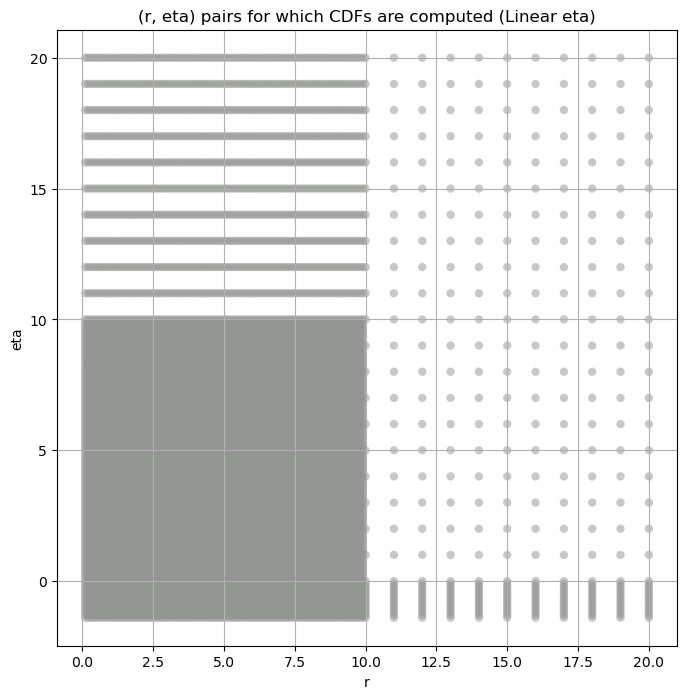

,"(r,eta),cdf",r,eta,cdf,variance,kurtosis
0,"((0.1, -1.4), <scipy.interpolate._fitpack2.Int...",0.1,-1.4,<scipy.interpolate._fitpack2.InterpolatedUniva...,3.628800e+06,554265.000000
1,"((0.1, -1.3), <scipy.interpolate._fitpack2.Int...",0.1,-1.3,<scipy.interpolate._fitpack2.InterpolatedUniva...,3.991680e+07,96192.272727
2,"((0.1, -1.2), <scipy.interpolate._fitpack2.Int...",0.1,-1.2,<scipy.interpolate._fitpack2.InterpolatedUniva...,2.395008e+08,29390.000000
3,"((0.1, -1.1), <scipy.interpolate._fitpack2.Int...",0.1,-1.1,<scipy.interpolate._fitpack2.InterpolatedUniva...,1.037837e+09,11997.692308
4,"((0.1, -1.0), <scipy.interpolate._fitpack2.Int...",0.1,-1.0,<scipy.interpolate._fitpack2.InterpolatedUniva...,3.632429e+09,5874.890110


In [12]:
warnings.filterwarnings('ignore', category=RuntimeWarning)

all_cdfs_df = create_kurt_var_ksstat_df(all_cdfs)
fine_cdfs_df = all_cdfs_df.copy()
all_cdfs_df = all_cdfs_df[(np.round(all_cdfs_df['r'], 1) == all_cdfs_df['r']) & (np.round(all_cdfs_df['eta'], 1) == all_cdfs_df['eta'])]
all_cdfs_df = all_cdfs_df.reset_index(drop=True)
all_cdfs = {x[0] : x[1] for x in all_cdfs_df["(r,eta),cdf"]}
                                             
var_values_dict = dict()
kurt_values_dict = dict()
master_df = pd.DataFrame(columns=[GROUP]).set_index(GROUP)
temp_cdf = all_cdfs_df
print(f"Running {all_cdfs_df.shape[0]} CDFs")
create_scatter_plot(all_cdfs_df);
all_cdfs_df.head()

## Bootstrapping the Variance and Kurtosis

In [13]:
n_bootstrap = int(1e5) # TODO For quick testing purposes
bootstrap_size = int(1e4) # TODO For quick testing purposes
ci = 0.99

In [14]:
bootstrap_path = Path(os.path.join(CWD, "CSVs", f'initial_grid_bootstrap{n_bootstrap}_{bootstrap_size}_ci{ci}.csv'))
master_df_var_kurt_path = Path(os.path.join(CWD, "CSVs", f'initial_grid_bootstrap{n_bootstrap}_{bootstrap_size}_ci{ci}.csv'))

if RERUN or not master_df_var_kurt_path.exists(): # TODO For quick testing purposes
    for group in GROUPS:
        print(f'{GROUP.capitalize()} {group}')
        obs_var, var_lower, var_upper, var_values_dict[group] = bootstrap_metric(group_data_map[group], 
                                                                                n_bootstrap=n_bootstrap, 
                                                                                bootstrap_size=min(group_data_map[group].size, bootstrap_size), 
                                                                                metric= np.var, 
                                                                                ci=ci)
        obs_kurt, kurt_lower, kurt_upper, kurt_values_dict[group] = bootstrap_metric(group_data_map[group], 
                                                                                    n_bootstrap=n_bootstrap, 
                                                                                    bootstrap_size=min(group_data_map[group].size, bootstrap_size), 
                                                                                    metric= stats.kurtosis, ci=ci)  
        master_df.loc[group, 'obs_var'], master_df.loc[group, 'var_lower'], master_df.loc[group, 'var_upper'] = obs_var, var_lower, var_upper
        master_df.loc[group, 'obs_kurt'], master_df.loc[group, 'kurt_lower'], master_df.loc[group, 'kurt_upper'] = obs_kurt, kurt_lower, kurt_upper
        master_df.loc[group, 'total_samples'] = group_total_samples[group]

    master_df.to_csv(os.path.join(CWD, "CSVs", f'initial_grid_bootstrap{n_bootstrap}_{bootstrap_size}_ci{ci}.csv'))

master_df = pd.read_csv(master_df_var_kurt_path, index_col=GROUP)
var_kurt_df = pd.read_csv(bootstrap_path, index_col=GROUP)
master_df

Layer 4


  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

Layer 5


  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

,obs_var,var_lower,var_upper,obs_kurt,kurt_lower,kurt_upper,total_samples
layer,,,,,,,
4,269349.47,260736.48,278172.380,-0.415785,-0.529325,-0.261257,177766.0
5,89765.79,85342.18,94362.086,1.816636,1.392845,2.339894,820632.0


## Initial Grid Search and Hypothesis Test Plots

In [15]:
EXCLUDE_CUTOFFS = [0, 25, 50, 75, 100, 150, 200, 250, 300, 350, 500] # TODO For quick testing purposes
SCALE_CAP = 1e5

In [16]:
augmented_var_df_path = Path(os.path.join(CWD, "CSVs", "augmented_var_df_ad.csv"))
augmented_var_df = var_kurt_df[['obs_var']].copy()
augmented_var_df
for val in EXCLUDE_CUTOFFS:
    temp_arr = []
    for group in GROUPS:
        if val != 0:
            temp_arr.append(np.var(group_data_map[group][val:-val]))
        else:
            temp_arr.append(np.var(group_data_map[group]))

    augmented_var_df[f"var_exclude_{val}"] = temp_arr
augmented_var_df

,obs_var,var_exclude_0,var_exclude_25,var_exclude_50,var_exclude_75,var_exclude_100,var_exclude_150,var_exclude_200,var_exclude_250,var_exclude_300,var_exclude_350,var_exclude_500
layer,,,,,,,,,,,,
4,269349.47,269349.468750,267502.15625,266254.625000,265186.593750,264230.18750,262476.15625,260888.015625,259405.281250,258001.937500,256648.734375,252800.015625
5,89765.79,89765.789062,88552.34375,87637.570312,86815.734375,86059.96875,84706.25000,83501.929688,82409.046875,81401.945312,80466.125000,77970.710938


####
Layer  4


  0%|          | 0/12760 [00:00<?, ?it/s]

Finding Minimum after computing 12760 CDFs
4 0 217.804765530283 269349.47


  0%|          | 0/12760 [00:00<?, ?it/s]

Finding Minimum after computing 12760 CDFs
4 25 231.94497920744445 267502.16


...

Finding Minimum after computing 12760 CDFs
4 300 325.66489281982604 258001.94


  0%|          | 0/12760 [00:00<?, ?it/s]

Finding Minimum after computing 12760 CDFs
4 350 342.47900299026503 256648.73


  0%|          | 0/12760 [00:00<?, ?it/s]

Finding Minimum after computing 12760 CDFs
4 500 395.0936965115564 252800.02
Number of samples: 100000, Without approximation : 177766.0


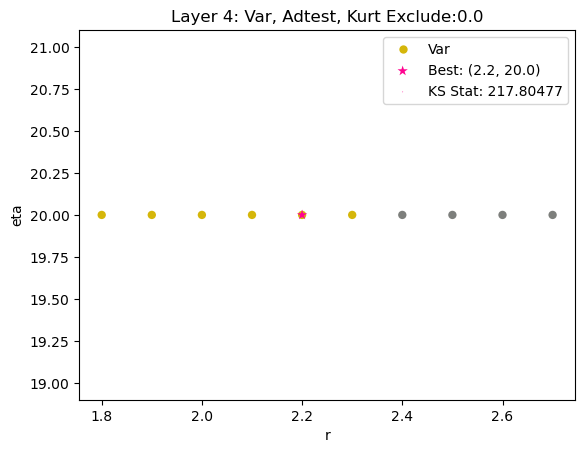

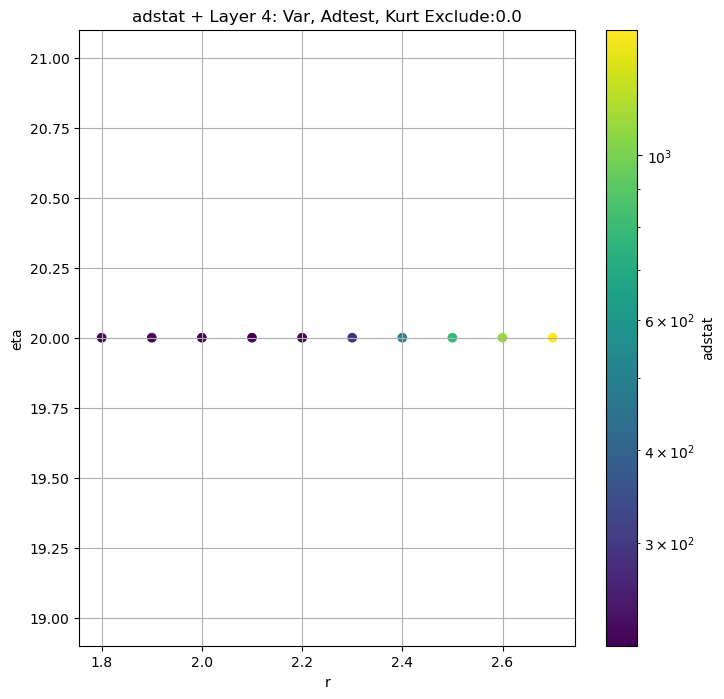

####
Layer  5


  0%|          | 0/12760 [00:00<?, ?it/s]

Finding Minimum after computing 12760 CDFs
5 0 24.47783424555216 89765.79


  0%|          | 0/12760 [00:00<?, ?it/s]

Finding Minimum after computing 12760 CDFs
5 25 24.37474498639827 88552.34


...

Finding Minimum after computing 12760 CDFs
5 300 118.09239424145693 81401.945


  0%|          | 0/12760 [00:00<?, ?it/s]

Finding Minimum after computing 12760 CDFs
5 350 152.992111126674 80466.125


  0%|          | 0/12760 [00:00<?, ?it/s]

Finding Minimum after computing 12760 CDFs
5 500 276.7590816302454 77970.71
Number of samples: 100000, Without approximation : 820632.0


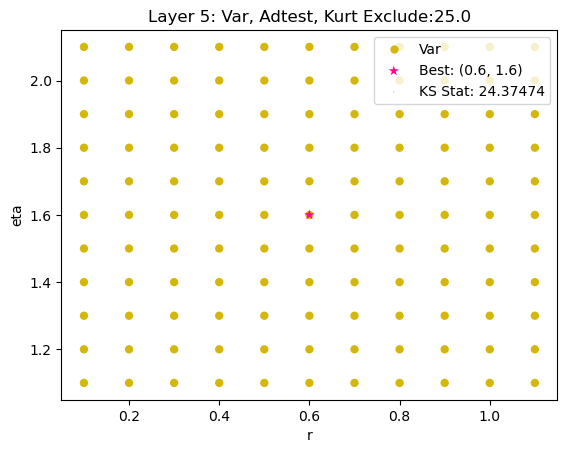

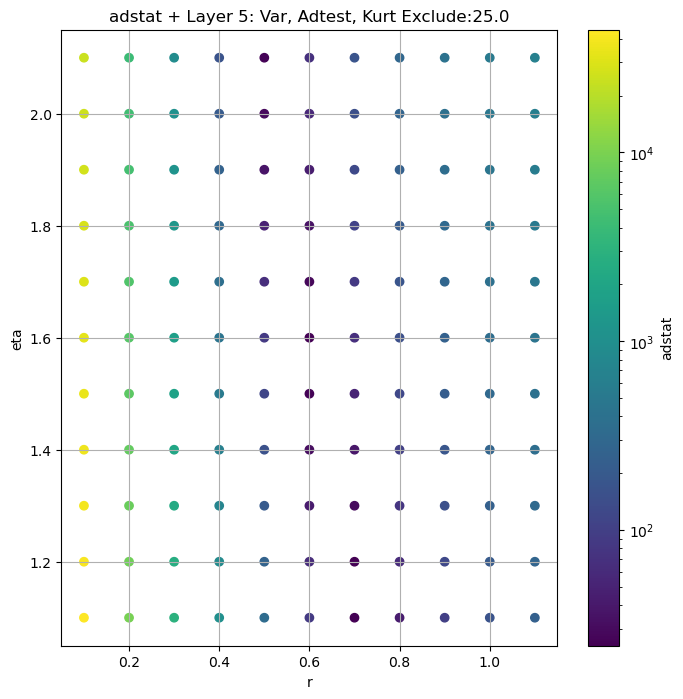

,obs_var,var_lower,var_upper,obs_kurt,kurt_lower,kurt_upper,total_samples,adtest_stat_initial,initial_r,initial_eta,initial_scale,initial_exclude_cutoff,best_augmented_var,adtest_stat_cutoff_0.05
layer,,,,,,,,,,,,,,
4,269349.47,260736.48,278172.380,-0.415785,-0.529325,-0.261257,177766.0,217.804766,2.2,20.0,96788.580679,0.0,269349.47,2.492367
5,89765.79,85342.18,94362.086,1.816636,1.392845,2.339894,820632.0,24.374745,0.6,1.6,5188.438469,25.0,88552.34,2.492367


In [17]:
master_df_combo_path = Path(os.path.join(CWD, "CSVs", "master_df_combo_ad.csv"))
rEtaAdstats_dict_path = Path(os.path.join(CWD, "cache", "rEtaAdstats_dict.pickle"))

rEtaAdstats_dict = dict()

# AD cutoff is n-independent (asymptotic distribution doesn't depend on sample size)
ad_cutoff = scipy.optimize.fsolve(lambda x: 1 - ad_asymptotic_cdf(x, N=10) - 0.05, 1)[0]

if RERUN or not master_df_combo_path.exists():
    sorted_params = sorted(all_cdfs)
    adstats_dict = dict()

    for i, group in enumerate(GROUPS): # TODO For quick testing purposes
        print(f"####\n{GROUP.capitalize()} ", group)
        sample = group_data_map[group]
        if len(sample) == 0:
            continue
        group_cdfs_df = all_cdfs_df.copy()
        true_n = group_total_samples[group]
        master_df.loc[group, 'adtest_stat_initial'] = np.inf

        for j in range(len(EXCLUDE_CUTOFFS)):

            exclude_cutoff = EXCLUDE_CUTOFFS[j]
            exclude_cutoff = int(exclude_cutoff)

            if exclude_cutoff == 0:
                augmented_var = np.var(group_data_map[group]) 
            else:
                augmented_var = np.var(group_data_map[group][exclude_cutoff:-exclude_cutoff])
                if augmented_var == np.var(group_data_map[group]):
                    continue 
                
            group_cdfs_df['scale'] = np.clip((augmented_var / group_cdfs_df['variance']), 0,  SCALE_CAP)
            adstats, initial_param, min_stat = gridsearch_ad(sample, all_cdfs, true_n=true_n, debug=True, scales=group_cdfs_df['scale'])
            augmented_var_df.loc[group, f"adtest_stat_{exclude_cutoff}"] = min_stat
            group_cdfs_df[f'adstat_exclude_{exclude_cutoff}'] = adstats
            
            print(group, exclude_cutoff, min_stat, augmented_var)
            
            if (min_stat < master_df.loc[group, 'adtest_stat_initial']) and not np.isclose(min_stat, master_df.loc[group, 'adtest_stat_initial'], 1e-6):
                initial_min_stat = min_stat
                initial_best_param = initial_param
                master_df.loc[group, 'adtest_stat_initial'] = min_stat
                initial_scale = group_cdfs_df.loc[(group_cdfs_df["r"] ==  initial_param[0]) & (group_cdfs_df["eta"] ==  initial_param[1])]["scale"].iloc[0]
                master_df.loc[group, 'initial_r'], master_df.loc[group, 'initial_eta'] = initial_param
                master_df.loc[group, 'initial_scale'] = initial_scale
                master_df.loc[group, 'initial_exclude_cutoff'] = exclude_cutoff
                master_df.loc[group, 'best_augmented_var'] = augmented_var
        
        adstats = group_cdfs_df[f"adstat_exclude_{int(master_df.loc[group, 'initial_exclude_cutoff'])}"]
            
        print(f"Number of samples: {sample.size}, Without approximation : {master_df.loc[group, 'total_samples']}")
        
        master_df.loc[group, 'adtest_stat_cutoff_0.05'] = ad_cutoff

        best_scales = np.clip((master_df.loc[group, 'best_augmented_var'] / group_cdfs_df['variance']), 0,  SCALE_CAP)

        group_cdfs_df['variance'] = group_cdfs_df['variance'] * best_scales
        group_cdfs_df['kurtosis'] = group_cdfs_df['kurtosis'] * best_scales

        group_cdfs_df = add_tests_to_df_ad(cdfs_df = group_cdfs_df, group = group, var_kurt_df = master_df, adstats = adstats, ad_cutoff = ad_cutoff).sort_values(['r', 'eta'])

        group_dict = {'r' : group_cdfs_df['r'], 'eta' : group_cdfs_df['eta']}
        group_dict.update({f'adstat_exclude_{exclude_cutoff}' : group_cdfs_df[f'adstat_exclude_{exclude_cutoff}'] for exclude_cutoff in EXCLUDE_CUTOFFS[:j+1]})
        rEtaAdstats_dict[group] = group_dict

        cols = ['pass_var', 'pass_adtest', 'pass_kurt']

        fig = combo_test_plot(group_cdfs_df, cols, 
                            plot_name=f"{GROUP.capitalize()} {group}: {', '.join([col[5:].capitalize() for col in cols])} Exclude:{master_df.loc[group, 'initial_exclude_cutoff']}", 
                            target_var = None,
                            best_param = initial_best_param,
                            best_ksstat=initial_min_stat,
                            metric = "adstat"
                            )
        
        fig.figure.savefig(os.path.join(CWD, "plots", f"full_grid_search_combo_plot_layer{group}.jpg"), bbox_inches = 'tight', dpi=100)

        # Optional: 
        # Create plots of bootstrapped variance and kurtosis for varying confidence intervals
        # fig_var = create_ci_scatter_plot(group_cdfs_df, var_values_dict, metric='variance', group=group)
        # fig_kurt = create_ci_scatter_plot(group_cdfs_df, kurt_values_dict, metric='kurtosis', group=group)

        # fig_var.savefig(os.path.join(CWD, "plots", f"ci_scatter_variance_{GROUP}_{group}_bootstrap{n_bootstrap}.jpg"), bbox_inches='tight')
        # plt.close(fig_var)
        # fig_kurt.savefig(os.path.join(CWD, "plots", f"ci_scatter_variance_{GROUP}_{group}_bootstrap{n_bootstrap}.jpg"), bbox_inches='tight')
        # plt.close(fig_kurt)

    master_df.to_csv(master_df_combo_path)
    pd.to_pickle(rEtaAdstats_dict, rEtaAdstats_dict_path)
    augmented_var_df.to_csv(augmented_var_df_path)

augmented_var_df = pd.read_csv(augmented_var_df_path, index_col=GROUP)
master_df = pd.read_csv(master_df_combo_path, index_col=GROUP)
rEtaAdstats_dict = pd.read_pickle(rEtaAdstats_dict_path)
master_df

## Optimization

In [18]:
master_df['adtest_stat_best'] = master_df['adtest_stat_initial']
master_df[f'best_r'] = master_df['initial_r']
master_df[f'best_eta'] = master_df['initial_eta']
master_df[f'best_scale'] = master_df['initial_scale']
master_df[f'best_exclude_cutoff'] = master_df['initial_exclude_cutoff']

Layer 4


  0%|          | 0/36 [00:00<?, ?it/s]

Finding Minimum after computing 36 CDFs
layer 4, 0.0 + 100 = 100, adstat: 260.4006492984871, var: 264230.1875


  0%|          | 0/36 [00:00<?, ?it/s]

Finding Minimum after computing 36 CDFs
layer 4, 0.0 + 75 = 75, adstat: 251.62305501499145, var: 265186.59375


...

Finding Minimum after computing 36 CDFs
layer 4, 0.0 + 50 = 50, adstat: 242.27269201227168, var: 266254.625


  0%|          | 0/36 [00:00<?, ?it/s]

Finding Minimum after computing 36 CDFs
layer 4, 0.0 + 25 = 25, adstat: 231.94497920744445, var: 267502.15625


  0%|          | 0/36 [00:00<?, ?it/s]

Finding Minimum after computing 36 CDFs
layer 4, 0.0 + 0 = 0, adstat: 217.804765530283, var: 269349.46875
Number of samples: 100000, Without approximation : 177766.0


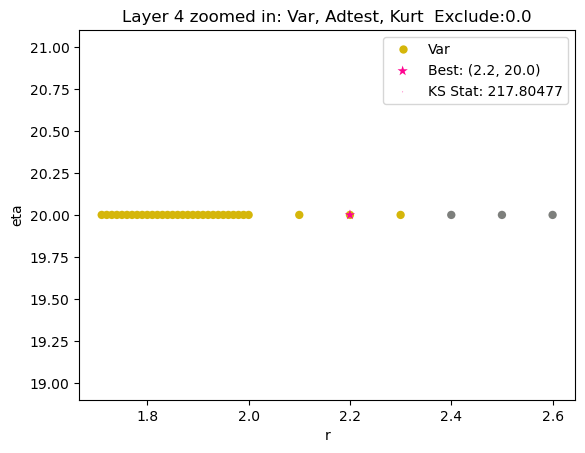

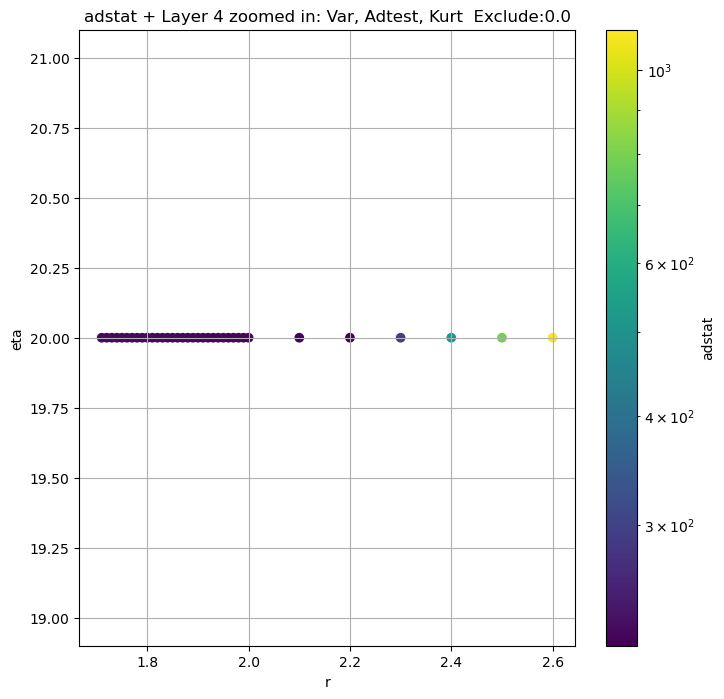

Layer 5


  0%|          | 0/891 [00:00<?, ?it/s]

Finding Minimum after computing 891 CDFs
layer 5, 25.0 + 100 = 125, adstat: 44.79632170202277, var: 85362.4140625


  0%|          | 0/891 [00:00<?, ?it/s]

Finding Minimum after computing 891 CDFs
layer 5, 25.0 + 75 = 100, adstat: 36.809606142830184, var: 86059.96875


...

Finding Minimum after computing 891 CDFs
layer 5, 25.0 + 25 = 50, adstat: 26.108526951390395, var: 87637.5703125


  0%|          | 0/891 [00:00<?, ?it/s]

Finding Minimum after computing 891 CDFs
layer 5, 25.0 + 0 = 25, adstat: 24.06028720258631, var: 88552.34375


  0%|          | 0/891 [00:00<?, ?it/s]

Finding Minimum after computing 891 CDFs
layer 5, 25.0 + -25 = 0, adstat: 24.47956810071995, var: 89765.7890625
Number of samples: 100000, Without approximation : 820632.0


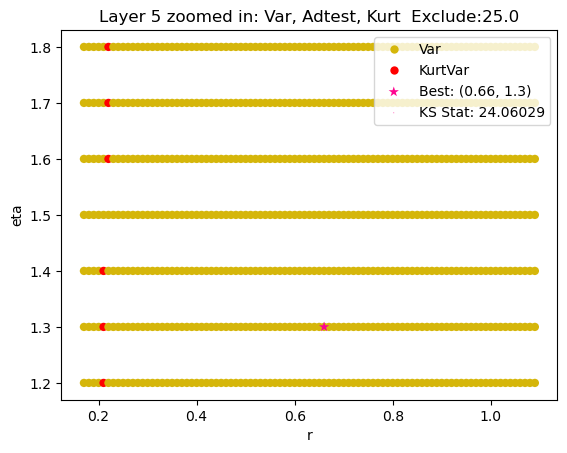

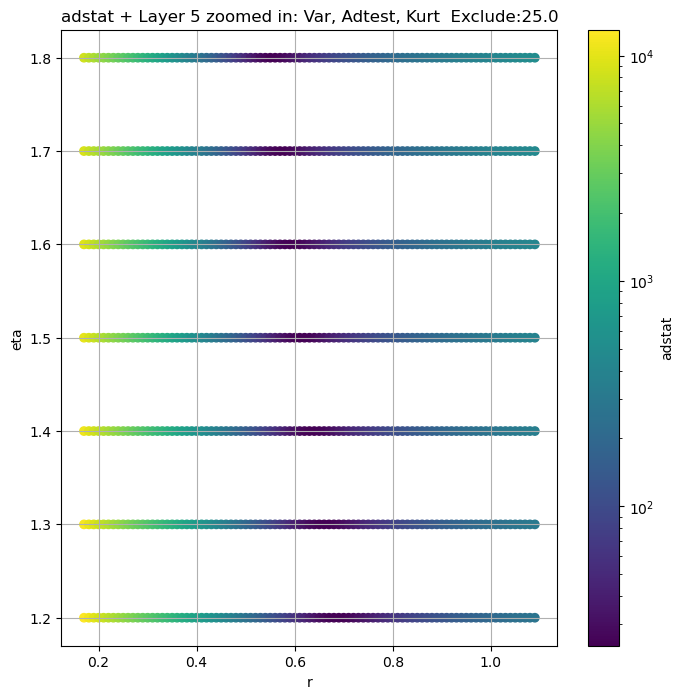

,obs_var,var_lower,var_upper,obs_kurt,kurt_lower,kurt_upper,total_samples,adtest_stat_initial,initial_r,initial_eta,initial_scale,initial_exclude_cutoff,best_augmented_var,adtest_stat_cutoff_0.05,adtest_stat_best,best_r,best_eta,best_scale,best_exclude_cutoff
layer,,,,,,,,,,,,,,,,,,,
4,269349.47,260736.48,278172.380,-0.415785,-0.529325,-0.261257,177766.0,217.804766,2.2,20.0,96788.580679,0.0,269349.47000,2.492367,217.804766,2.20,20.0,96788.580679,0.0
5,89765.79,85342.18,94362.086,1.816636,1.392845,2.339894,820632.0,24.374745,0.6,1.6,5188.438469,25.0,88552.34375,2.492367,24.060287,0.66,1.3,9104.125797,25.0


In [21]:
master_df_optimized_path = Path(os.path.join(CWD, "CSVs", 'master_df_optimized_ad.csv'))

NUM_ITERS = dict(zip(GROUPS, [1]*len(GROUPS))) # By default, does one iteration per group
NUM_SAMPLES_OPTIMIZE = 2000
EXCLUDE_CUTOFFS_OPTIMIZE = np.arange(100, -101, -25)

if RERUN or not master_df_optimized_path.exists():

    if SKIP_OPTIMIZE_STEP:

        master_df['adtest_stat_best'] = master_df['adtest_stat_initial']
        master_df[f'best_r'] = master_df['initial_r']
        master_df[f'best_eta'] = master_df['initial_eta']
        master_df[f'best_scale'] = master_df['initial_scale']
        master_df[f'best_exclude_cutoff'] = master_df['initial_exclude_cutoff']

    else:
        for group in GROUPS: # TODO For quick testing purposes
            print(f"{GROUP.capitalize()} {group}")
            master_df.loc[group, 'adtest_stat_best'] = master_df.loc[group, 'adtest_stat_initial']
            master_df.loc[group, 'best_r'] = master_df.loc[group, 'initial_r']
            master_df.loc[group, 'best_eta'] = master_df.loc[group, 'initial_eta']
            master_df.loc[group, 'best_scale'] = master_df.loc[group, 'initial_scale']

            sample = group_data_map[group]
            if len(sample) == 0:
                continue
            true_n = group_total_samples[group]
            initial_r, initial_eta = master_df.loc[group, 'initial_r'], master_df.loc[group, f'initial_eta']
            eps = 0.5
            group_cdfs_df = fine_cdfs_df[(np.abs(master_df.loc[group, 'initial_r'] - fine_cdfs_df['r']) < eps) & 
                                        (np.abs(master_df.loc[group, 'initial_eta'] - fine_cdfs_df['eta']) < eps)].reset_index(drop=True)
            group_cdfs = {x[0]:x[1] for x in group_cdfs_df['(r,eta),cdf']}

            for adjust_exclude_cutoff in EXCLUDE_CUTOFFS_OPTIMIZE: # -50, -25, 0, 25, 50
                
                exclude_cutoff = int(max(0, adjust_exclude_cutoff + master_df.loc[group, 'initial_exclude_cutoff']))
                
                if exclude_cutoff == 0:
                    augmented_var = np.var(group_data_map[group])
                else:
                    augmented_var = np.var(group_data_map[group][exclude_cutoff:-exclude_cutoff])                       

                group_cdfs_df['scale'] = np.clip((augmented_var / group_cdfs_df['variance']), 0,  SCALE_CAP)
                adstats, initial_param, min_stat = gridsearch_ad(sample, group_cdfs, true_n=true_n, debug=True, scales=group_cdfs_df['scale'])
                
                cutoff_label = generate_cutoff_label(adjust_exclude_cutoff)

                augmented_var_df.loc[group, f"adtest_stat_{cutoff_label}"] = min_stat
                group_cdfs_df[f'adstat_exclude_{cutoff_label}'] = adstats
                
                print(f"{GROUP} {group}, {master_df.loc[group, 'initial_exclude_cutoff']} + {adjust_exclude_cutoff} = {exclude_cutoff}, adstat: {min_stat}, var: {augmented_var}")
                best_adjust = 0

                if min_stat < master_df.loc[group, 'adtest_stat_best']:

                    initial_min_stat = min_stat
                    initial_best_param = initial_param
                    master_df.loc[group, 'adtest_stat_best'] = min_stat
                    initial_scale = group_cdfs_df.loc[(group_cdfs_df["r"] ==  initial_param[0]) & (group_cdfs_df["eta"] ==  initial_param[1])]["scale"].iloc[0]
                    master_df.loc[group, 'best_r'], master_df.loc[group, 'best_eta'] = initial_param
                    master_df.loc[group, 'best_scale'] = initial_scale
                    master_df.loc[group, 'best_exclude_cutoff'] = exclude_cutoff
                    master_df.loc[group, 'best_augmented_var'] = augmented_var
                    augmented_var_df.loc[group, 'best_augmented_var'] = augmented_var
                    best_adjust = adjust_exclude_cutoff

                if exclude_cutoff == 0:
                    break

            cutoff_label = generate_cutoff_label(best_adjust)
            adstats = group_cdfs_df[f"adstat_exclude_{cutoff_label}"]
            
            print(f"Number of samples: {sample.size}, Without approximation : {master_df.loc[group, 'total_samples']}")
            
            master_df.loc[group, 'adtest_stat_cutoff_0.05'] = ad_cutoff

            best_scales = np.clip((master_df.loc[group, 'best_augmented_var'] / group_cdfs_df['variance']), 0,  SCALE_CAP)

            group_cdfs_df['variance'] = group_cdfs_df['variance'] * best_scales
            group_cdfs_df['kurtosis'] = group_cdfs_df['kurtosis'] * best_scales

            group_cdfs_df = add_tests_to_df_ad(cdfs_df = group_cdfs_df, group = group, var_kurt_df = master_df, adstats = adstats, ad_cutoff = ad_cutoff).sort_values(['r', 'eta'])

            group_dict = rEtaAdstats_dict[group]
            group_dict.update({'r_optimize' : group_cdfs_df['r'], 'eta_optimize' : group_cdfs_df['eta'], f'adstat_exclude_{cutoff_label}' : adstats})
            rEtaAdstats_dict[group] = group_dict

            cols = ['pass_var', 'pass_adtest', 'pass_kurt']
            fig = combo_test_plot(group_cdfs_df, cols, 
                                plot_name=f"{GROUP.capitalize()} {group} zoomed in: {', '.join([col[5:].capitalize() for col in cols])}  Exclude:{master_df.loc[group, 'best_exclude_cutoff']}",
                                best_param=(master_df.loc[group, 'best_r'], master_df.loc[group, f'best_eta']),
                                best_ksstat=master_df.loc[group, 'adtest_stat_best'],
                                metric="adstat")
            fig.figure.savefig(os.path.join(CWD, "plots", f"optimized_full_grid_search_combo_plot_layer{group}.jpg"), bbox_inches = 'tight', dpi=100)
            
    # No n_pval_0.05 for AD (asymptotic distribution is n-independent)
    master_df[['total_samples', 'initial_r', 'initial_eta', 'adtest_stat_initial', 'initial_exclude_cutoff', 'best_r', 'best_eta', 'best_scale', 'adtest_stat_best', 'best_exclude_cutoff']].to_csv(os.path.join(CWD, "CSVs", 'optimized_params_ad.csv'))
    master_df.to_csv(os.path.join(CWD, "CSVs", 'master_df_optimized_ad.csv'))
    augmented_var_df.to_csv(augmented_var_df_path)
    pd.to_pickle(rEtaAdstats_dict, rEtaAdstats_dict_path)

rEtaAdstats_dict = pd.read_pickle(rEtaAdstats_dict_path)
master_df = pd.read_csv(master_df_optimized_path, index_col = GROUP)
augmented_var_df = pd.read_csv(augmented_var_df_path, index_col = GROUP)
master_df

## Comparing Empirical and Computed CDF/PDF

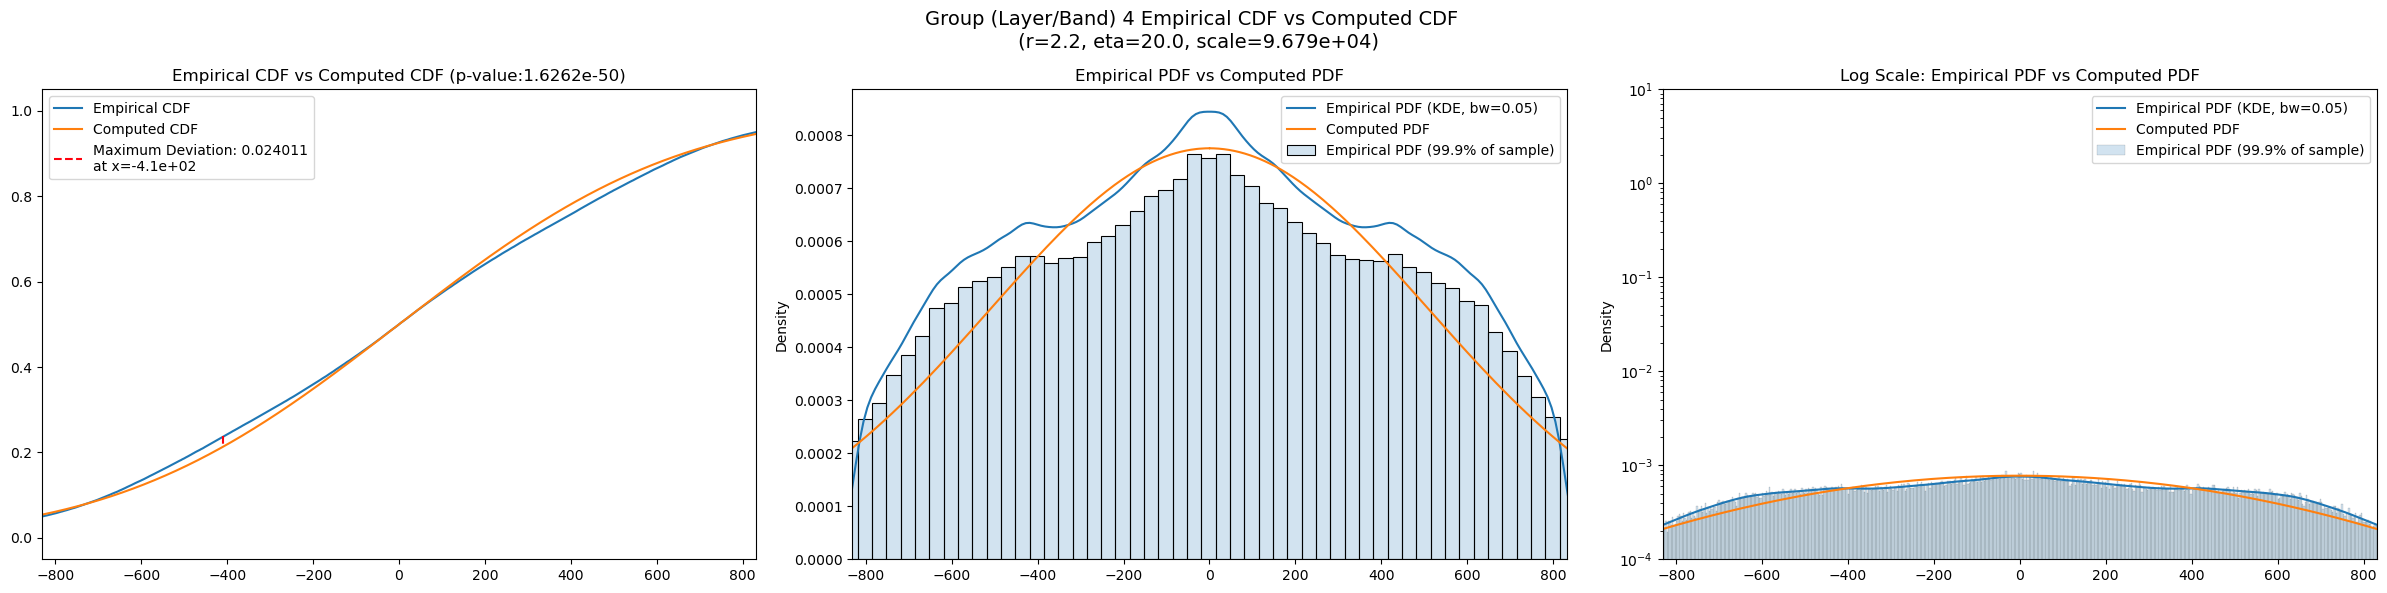

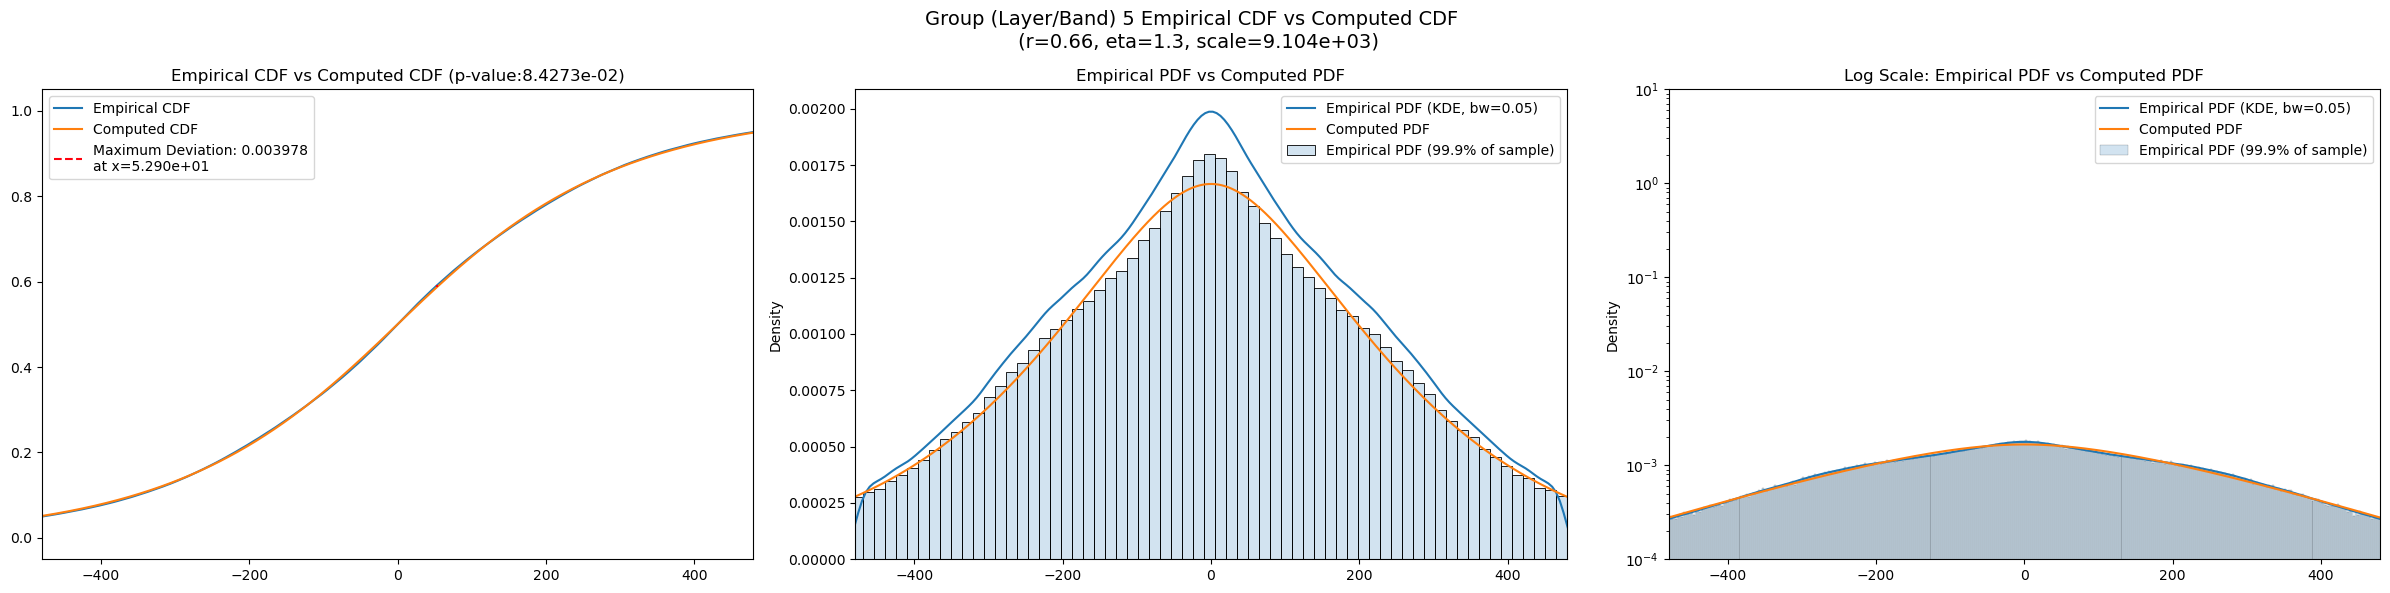

In [22]:
for group in GROUPS:
    group_info = master_df.loc[group]
    best_r = group_info['best_r']
    best_eta = group_info['best_eta']
    best_scale = group_info['best_scale']
    fig = visualize_cdf_pdf(sample = group_data_map[group], 
                    params = (best_r, best_eta, best_scale), 
                    log_scale = True,
                    group = group)
    fig.savefig(os.path.join(CWD, "plots", f'compare_cdf_pdf_layer_{group}.jpg'), bbox_inches = 'tight', dpi = 100)

## Comparing with Gaussian and Laplace Priors

In [ ]:
def generate_func_ad(sample, distro, *args, true_n=None, n_samples=200):
    if distro == 'gaussian' or distro == 'normal':
        def var_func(var):
            cdf = scipy.stats.norm(scale=var).cdf
            return compute_adstat(sample, cdf, true_n=true_n)
        return var_func
    elif distro == 'laplace':
        def var_func(var):
            cdf = scipy.stats.laplace(scale=var).cdf
            return compute_adstat(sample, cdf, true_n=true_n)
        return var_func
    elif distro == 't':
        def var_func(var):
            cdf = scipy.stats.t(df=2, scale=var).cdf
            return compute_adstat(sample, cdf, true_n=true_n)
        return var_func
    elif distro == 'prior_r':
        eta = args[0]
        def r_func(r):
            cdf = compute_prior_cdf(r, eta, n_samples=n_samples)
            return compute_adstat(sample, cdf, true_n=true_n)
        return r_func
    elif distro == 'prior_eta':
        r = args[0]
        def eta_func(eta):
            cdf = compute_prior_cdf(r, eta, n_samples=n_samples)
            return compute_adstat(sample, cdf, true_n=true_n)
        return eta_func
    elif distro == 'prior':
        def r_eta_func(params):
            r = params[0]
            eta = params[1]
            cdf = compute_prior_cdf(r, eta, n_samples=n_samples, debug=False)
            return compute_adstat(sample, cdf, true_n=true_n)
        return r_eta_func
    elif distro == 'prior_with_scale':
        def r_eta_scale_func(params):
            r = params[0]
            eta = params[1]
            scale = params[2]
            print(r, eta, scale)
            cdf = compute_prior_cdf(r = r, eta = eta, n_samples=n_samples, debug=False)
            return compute_adstat(sample/ np.sqrt(scale), cdf, true_n=true_n)
        return r_eta_scale_func

    print("Please enter a valid argument for `distro`: 'gaussian', 'laplace', 'prior_r', 'prior_eta', 'prior','prior_with_scale', 't'")

In [ ]:
master_df_path = Path(os.path.join(CWD, "CSVs", 'master_df_ad.csv'))

if RERUN or not master_df_path.exists():
    upper_bound = int(1e6)
    for group in GROUPS:
        if len(group_data_map[group]) == 0:
            continue
        true_n = group_total_samples[group]
        norm_result = scipy.optimize.minimize_scalar(generate_func_ad(group_data_map[group], 'gaussian', true_n=true_n), method = 'bounded', bounds = (0, upper_bound))
        laplace_result = scipy.optimize.minimize_scalar(generate_func_ad(group_data_map[group], 'laplace', true_n=true_n), method = 'bounded', bounds = (0, upper_bound))
        t_result = scipy.optimize.minimize_scalar(generate_func_ad(group_data_map[group], 't', true_n=true_n), method = 'bounded', bounds = (0, upper_bound))
        
        master_df.loc[group, 'param_gaussian'] = round_to_sigfigs(norm_result['x'], 6)
        master_df.loc[group, 'adtest_stat_gaussian'] = round_to_sigfigs(norm_result['fun'], 6)
        master_df.loc[group, 'adtest_pval_gaussian'] = round_to_sigfigs(1 - ad_asymptotic_cdf(master_df.loc[group, 'adtest_stat_gaussian']), 6)

        master_df.loc[group, 'param_laplace'] = round_to_sigfigs(laplace_result['x'], 6)
        master_df.loc[group, 'adtest_stat_laplace'] = round_to_sigfigs(laplace_result['fun'], 6)
        master_df.loc[group, 'adtest_pval_laplace'] = round_to_sigfigs(1 - ad_asymptotic_cdf(master_df.loc[group, 'adtest_stat_laplace']), 6)

        master_df.loc[group, 'param_t'] = round_to_sigfigs(t_result['x'], 6)
        master_df.loc[group, 'adtest_stat_t'] = round_to_sigfigs(t_result['fun'], 6)
        master_df.loc[group, 'adtest_pval_t'] = round_to_sigfigs(1 - ad_asymptotic_cdf(master_df.loc[group, 'adtest_stat_t']), 6) 

        master_df.loc[group, 'adtest_pval_gengamma'] = round_to_sigfigs(1 - ad_asymptotic_cdf(master_df.loc[group, 'adtest_stat_best']), 6)

    master_df.to_csv(os.path.join(CWD, "CSVs", 'master_df_ad.csv'))
    
master_df = pd.read_csv(os.path.join(CWD, "CSVs", 'master_df_ad.csv'), index_col = GROUP)
master_df

## Results

In [ ]:
import pandas as pd
import os
master_df = pd.read_csv(os.path.join(os.getcwd(), "CSVs", 'master_df_ad.csv'), index_col = 0)

In [ ]:
master_df.filter(regex="adtest_stat.*")

In [ ]:
master_df.filter(regex="best.*")

,best_augmented_var,kstest_stat_best,best_r,best_eta,best_scale,best_exclude_cutoff
layer,,,,,,
2,NaN,1.000000,NaN,NaN,NaN,NaN
3,170305.000000,0.021379,3.30,20.00,98104.240306,0.0
4,269349.470000,0.024011,2.20,20.00,96788.580679,0.0
5,86815.734375,0.002832,1.52,0.10,92684.255325,75.0
6,24632.085938,0.003845,1.10,-0.75,36644.981469,200.0
7,5311.806152,0.004484,0.70,-0.89,4975.299048,175.0
8,732.881775,0.002817,0.40,-0.83,88.266105,25.0
9,72.970909,0.001954,0.21,-0.50,0.009796,0.0
